In [1]:
# from freeqdsk import geqdsk

# with open("g_file.in", 'r') as f:
#     g = geqdsk.read(f)

In [25]:
from resources import psiBfield
import importlib
importlib.reload(psiBfield)

g = psiBfield.extract_g()

g_file keywords extracted


In [26]:
g.z_grid[0, :]

array([-1.6  , -1.575, -1.55 , -1.525, -1.5  , -1.475, -1.45 , -1.425,
       -1.4  , -1.375, -1.35 , -1.325, -1.3  , -1.275, -1.25 , -1.225,
       -1.2  , -1.175, -1.15 , -1.125, -1.1  , -1.075, -1.05 , -1.025,
       -1.   , -0.975, -0.95 , -0.925, -0.9  , -0.875, -0.85 , -0.825,
       -0.8  , -0.775, -0.75 , -0.725, -0.7  , -0.675, -0.65 , -0.625,
       -0.6  , -0.575, -0.55 , -0.525, -0.5  , -0.475, -0.45 , -0.425,
       -0.4  , -0.375, -0.35 , -0.325, -0.3  , -0.275, -0.25 , -0.225,
       -0.2  , -0.175, -0.15 , -0.125, -0.1  , -0.075, -0.05 , -0.025,
        0.   ,  0.025,  0.05 ,  0.075,  0.1  ,  0.125,  0.15 ,  0.175,
        0.2  ,  0.225,  0.25 ,  0.275,  0.3  ,  0.325,  0.35 ,  0.375,
        0.4  ,  0.425,  0.45 ,  0.475,  0.5  ,  0.525,  0.55 ,  0.575,
        0.6  ,  0.625,  0.65 ,  0.675,  0.7  ,  0.725,  0.75 ,  0.775,
        0.8  ,  0.825,  0.85 ,  0.875,  0.9  ,  0.925,  0.95 ,  0.975,
        1.   ,  1.025,  1.05 ,  1.075,  1.1  ,  1.125,  1.15 ,  1.175,
      

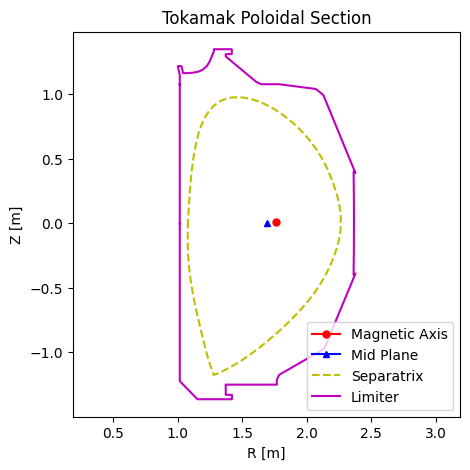

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.plot(g.rmaxis, g.zmaxis, 'r', marker = 'o', markersize = 5, label = "Magnetic Axis")
plt.plot(g.rcentr, g.zmid, 'b',marker = '^', markersize = 5, label = "Mid Plane")
plt.plot(g.rbdry, g.zbdry, 'y--', label = "Separatrix")
plt.plot(g.rlim, g.zlim, 'm', label = "Limiter")
plt.title("Tokamak Poloidal Section")
plt.xlim(g.r_grid[:,0][0], g.r_grid[:,0][-1])
plt.ylim(g.z_grid[0,:][0], g.z_grid[0,:][-1])
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.axis('equal')
plt.legend()
plt.show()

In [28]:
g.rdim, g.nr

(np.float64(1.7), 129)

In [29]:
# import numpy as np
# r_coords = np.linspace(g.rleft, g.rleft + g.rdim, g.nr)
# z_coords = np.linsapce(g.zmid - g.zdim/2 + g.zmid + g.zdim/2, g.nz)

In [30]:
r_coords = g.r_grid[:,0]
z_coords = g.z_grid[0,:]

/tmp/ipykernel_1042/1801196969.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


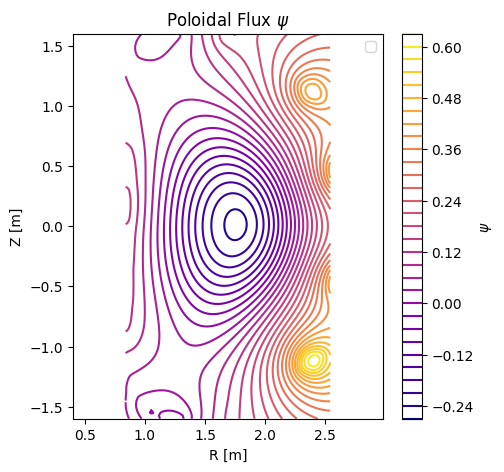

In [31]:
plt.figure(figsize = (5,5))

plt.contour(g.r_grid, g.z_grid, g.psi, levels = 30, cmap = 'plasma')
plt.colorbar(label = r'$\psi$')
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.title(r"Poloidal Flux $\psi$")
plt.axis('equal')
plt.legend()
plt.show()

In [32]:
psi_norm = (g.psi - g.simagx)/(g.psi.max() - g.psi.min())

/tmp/ipykernel_1042/1103649705.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


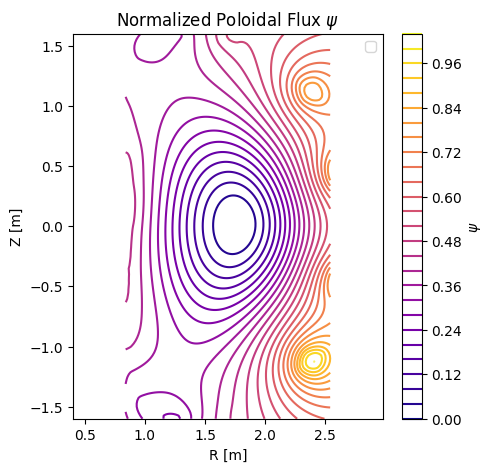

In [33]:
plt.figure(figsize = (5,5))

plt.contour(g.r_grid, g.z_grid, psi_norm, levels = 30, cmap = 'plasma')
plt.colorbar(label = r'$\psi$')
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.title(r"Normalized Poloidal Flux $\psi$")
plt.axis('equal')
plt.legend()
plt.show()

In [34]:
import numpy as np
dpsi_dR = np.gradient(psi_norm, r_coords, axis = 0)
dpsi_dZ = np.gradient(psi_norm, z_coords, axis =1)

In [35]:
BR = - (1/r_coords) * dpsi_dZ
BZ = (1/r_coords) * dpsi_dR

/tmp/ipykernel_1042/2374298948.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


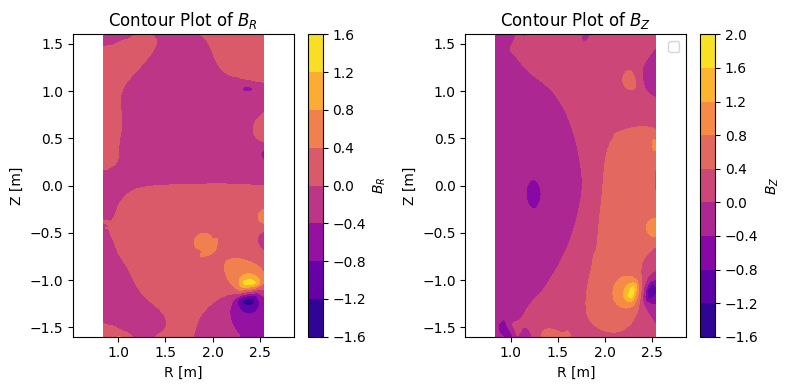

In [36]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.contourf(g.r_grid, g.z_grid, BR, cmap = 'plasma')
plt.colorbar(label = r"$B_R$")
plt.xlabel('R [m]')
plt.ylabel('Z [m]')
plt.axis('equal')
plt.title(r'Contour Plot of $B_R$')

plt.subplot(1,2,2)
plt.contourf(g.r_grid, g.z_grid, BZ, cmap = 'plasma')
plt.colorbar(label = r"$B_Z$")
plt.xlabel('R [m]')
plt.ylabel('Z [m]')
plt.axis('equal')
plt.title(r'Contour Plot of $B_Z$')

plt.legend()
plt.tight_layout()
plt.show()


In [37]:
from scipy.interpolate import interp1d

psi_grid = np.linspace(g.psi.min(), g.psi.max(), len(g.fpol))
fpol_interp = interp1d(psi_grid, g.fpol)

B_phi = fpol_interp(g.psi)/r_coords


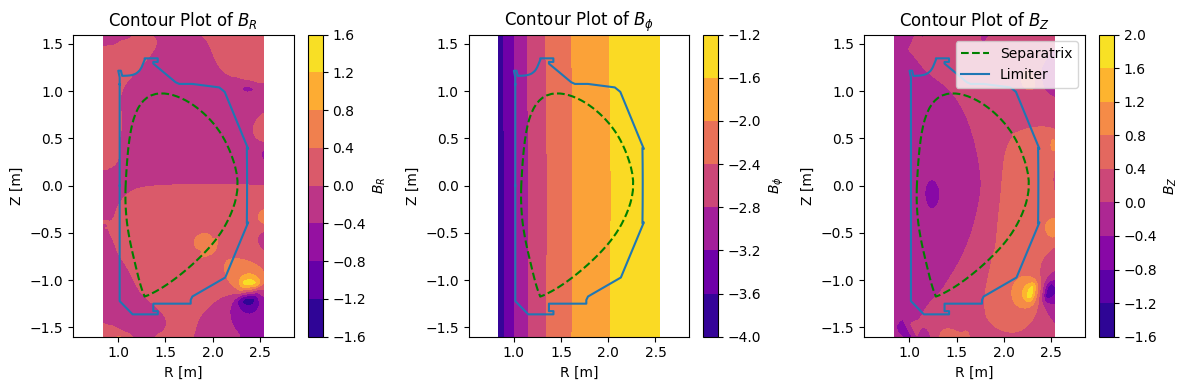

In [38]:
plt.figure(figsize = (12,4))

plt.subplot(1,3,1)
plt.contourf(g.r_grid, g.z_grid, BR, cmap = 'plasma')
plt.colorbar(label = r'$B_R$')
plt.xlabel('R [m]')
plt.ylabel('Z [m]')
plt.axis('equal')
plt.plot(g.rbdry, g.zbdry, 'g--', label = 'Separatrix')
plt.plot(g.rlim, g.zlim, label = 'Limiter')
plt.title(r'Contour Plot of $B_R$')

plt.subplot(1,3,2)
plt.contourf(g.r_grid, g.z_grid, B_phi.T, cmap = 'plasma')
plt.colorbar(label = r'$B_{\phi}$')
plt.xlabel('R [m]')
plt.ylabel('Z [m]')
plt.axis('equal')
plt.plot(g.rbdry, g.zbdry, 'g--', label = 'Separatrix')
plt.plot(g.rlim, g.zlim, label = 'Limiter')
plt.title(r'Contour Plot of $B_{\phi}$')

plt.subplot(1,3,3)
plt.contourf(g.r_grid, g.z_grid, BZ, cmap = 'plasma')
plt.colorbar(label = r'$B_Z$')
plt.xlabel('R [m]')
plt.ylabel('Z [m]')
plt.axis('equal')
plt.plot(g.rbdry, g.zbdry, 'g--', label = 'Separatrix')
plt.plot(g.rlim, g.zlim, label = 'Limiter')
plt.title(r'Contour Plot of $B_Z$')

plt.legend()
plt.tight_layout()
plt.show()


In [39]:
from scipy.interpolate import RegularGridInterpolator

BR_interp = RegularGridInterpolator((r_coords, z_coords), BR)
BZ_interp = RegularGridInterpolator((r_coords, z_coords), BZ)


In [40]:
def RK4(F, r_current, z_current, h):
  k1r, k1z = F(r_current, z_current)
  k2r, k2z = F(r_current + 0.5*h*k1r, z_current + 0.5*h*k1z)
  k3r, k3z = F(r_current + 0.5*h*k2r, z_current + 0.5*h*k2z)
  k4r, k4z = F(r_current + h*k3r, z_current + h*k3z)

  r_new = r_current + (h/6)*(k1r + 2*k2r + 2*k3r + k4r)
  z_new = z_current + (h/6)*(k1z + 2*k2z + 2*k3z + k4z)
  return r_new, z_new

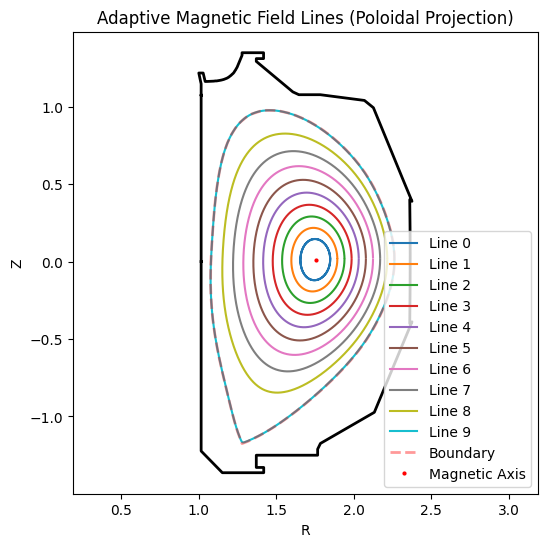

In [24]:
from scipy.interpolate import RegularGridInterpolator

r_start = np.linspace(g.rmagx + 0.09, g.rbdry.max() - 0.0001, 10)
z_start = g.zmaxis
tolerance = 1e-2
initial_h = -0.001

psi_interp = RegularGridInterpolator((r_coords, z_coords), g.psi)

r_trajectory = []
z_trajectory = []

plt.figure(figsize=(6,6))

for i, r_initial in enumerate(r_start):
    r_current = r_initial
    z_current = z_start

    psi_start = psi_interp(np.array([[r_current, z_current]]))[0]

    r_trajectory.append([r_current])
    z_trajectory.append([z_current])

    max_step = 50000
    step_count = 0


    while (step_count < max_step):

        psi_current = psi_interp(np.array([[r_current, z_current]]))[0]

        step_count += 1
        h_current_step = initial_h

        # Adaptive step refinement loop
        refined_step_found = False
        for _ in range(15):
            r_new_candidate, z_new_candidate = RK4(F, r_current, z_current, h_current_step)

            psi_new = psi_interp(np.array([[r_new_candidate, z_new_candidate]]))[0]

            if abs(psi_new - psi_start) < tolerance:
                r_new, z_new = r_new_candidate, z_new_candidate
                refined_step_found = True
                break
            else:
                h_current_step /= 2.0
                if h_current_step < 1e-7:
                    r_new, z_new = r_new_candidate, z_new_candidate
                    refined_step_found = True
                    break

        if step_count >1000:
          if  abs(r_initial - r_new) < 1e-4:
            break

        r_current, z_current = r_new, z_new

        r_trajectory[i].append(r_new)
        z_trajectory[i].append(z_new)



    plt.plot(r_trajectory[i], z_trajectory[i], label=f"Line {i}")

plt.plot(g.rbbbs, g.zbbbs, 'r--', linewidth=2, alpha=0.4, label='Boundary')
plt.plot(g.rmaxis, g.zmaxis, 'ro', markersize=2, label='Magnetic Axis')
plt.plot(g.rlim, g.zlim, 'k', linewidth=2)
plt.axis('equal')
plt.xlabel("R")
plt.ylabel("Z")
plt.title("Adaptive Magnetic Field Lines (Poloidal Projection)")
plt.legend()
plt.show()